## 1. Import Required Libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

## 2. Load the Dataset

In [67]:
df = pd.read_csv("logistics_shipment_data_2000.csv")
df


,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
0,SH10001,Mumbai_Warehouse,Hyderabad,DHL,2025-02-02,2025-02-08,8.1,979.63,Delivered,2202,6
1,SH10002,Delhi_Warehouse,Kolkata,Delhivery,2025-10-10,2025-10-14,6.9,186.22,Delivered,202,4
2,SH10003,Bengaluru_Warehouse,Ahmedabad,BlueDart,2025-08-27,2025-08-30,11.6,685.09,Delivered,1024,3
3,SH10004,Delhi_Warehouse,Kolkata,DHL,2025-06-10,2025-06-14,11.1,646.05,Delivered,1173,4
4,SH10005,Hyderabad_Warehouse,Delhi,Delhivery,2025-06-08,2025-06-14,15.1,1044.77,Delivered,2005,6
...,...,...,...,...,...,...,...,...,...,...,...
2005,SH10960,Pune_Warehouse,Ahmedabad,Ecom Express,2025-05-31,2025-06-05,38.0,854.84,Delivered,1221,5
2006,SH10873,Bengaluru_Warehouse,Nagpur,Delhivery,2025-02-11,2025-02-17,26.3,1227.00,Delivered,2055,6
2007,SH10038,Delhi_Warehouse,Ahmedabad,BlueDart,2025-10-30,2025-10-31,12.6,346.91,Delivered,148,1
2008,SH10412,Bengaluru_Warehouse,Nashik,DHL,2025-03-25,2025-03-26,19.0,237.64,Delivered,171,1


In [68]:
df.head()

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
0,SH10001,Mumbai_Warehouse,Hyderabad,DHL,2025-02-02,2025-02-08,8.1,979.63,Delivered,2202,6
1,SH10002,Delhi_Warehouse,Kolkata,Delhivery,2025-10-10,2025-10-14,6.9,186.22,Delivered,202,4
2,SH10003,Bengaluru_Warehouse,Ahmedabad,BlueDart,2025-08-27,2025-08-30,11.6,685.09,Delivered,1024,3
3,SH10004,Delhi_Warehouse,Kolkata,DHL,2025-06-10,2025-06-14,11.1,646.05,Delivered,1173,4
4,SH10005,Hyderabad_Warehouse,Delhi,Delhivery,2025-06-08,2025-06-14,15.1,1044.77,Delivered,2005,6


## 3. Initial Dataset Exploration

In [69]:
df.shape

(2010, 11)

In [70]:
df.columns

Index(['Shipment_ID', 'Origin_Warehouse', 'Destination', 'Carrier',
       'Shipment_Date', 'Delivery_Date', 'Weight_kg', 'Cost', 'Status',
       'Distance_miles', 'Transit_Days'],
      dtype='object')

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Shipment_ID       2010 non-null   object 
 1   Origin_Warehouse  2010 non-null   object 
 2   Destination       2010 non-null   object 
 3   Carrier           2005 non-null   object 
 4   Shipment_Date     2010 non-null   object 
 5   Delivery_Date     1981 non-null   object 
 6   Weight_kg         2010 non-null   float64
 7   Cost              1970 non-null   float64
 8   Status            2010 non-null   object 
 9   Distance_miles    2010 non-null   int64  
 10  Transit_Days      2010 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 172.9+ KB


In [72]:
df.describe()

,Weight_kg,Cost,Distance_miles,Transit_Days
count,2010.000000,1970.000000,2010.000000,2010.000000
mean,23.157463,807.323401,1280.737811,4.232338
std,43.028270,375.484913,705.186440,1.695087
min,1.300000,63.810000,51.000000,1.000000
25%,11.200000,534.295000,651.250000,3.000000
50%,18.500000,795.175000,1262.500000,4.000000
75%,27.500000,1062.190000,1891.000000,6.000000
max,1200.000000,6500.000000,2499.000000,9.000000


 ## 4. Missing Value Analysis

In [73]:
df.isnull().sum()

Shipment_ID          0
Origin_Warehouse     0
Destination          0
Carrier              5
Shipment_Date        0
Delivery_Date       29
Weight_kg            0
Cost                40
Status               0
Distance_miles       0
Transit_Days         0
dtype: int64

In [74]:
df.isnull().sum().sum()

np.int64(74)

### Missing Value Assessment

The dataset was examined for missing values using Pandas. Missing values were identified in the Cost, Delivery_Date, and Carrier columns. These missing records will be investigated and handled using appropriate preprocessing techniques rather than being removed without analysis.

## 5. Duplicate Record Detection

In [75]:
df.duplicated().sum()

np.int64(10)

In [76]:
df[df.duplicated()]

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
2000,SH10965,Ahmedabad_Warehouse,Delhi,BlueDart,2025-12-13,2025-12-18,7.9,885.94,Delivered,1848,5
2001,SH11122,Mumbai_Warehouse,Kolkata,Ecom Express,2025-01-31,2025-02-05,13.9,1212.56,Delayed,2498,5
2002,SH10936,Bengaluru_Warehouse,Jaipur,Ecom Express,2025-12-10,2025-12-12,42.3,617.43,Delivered,610,2
2003,SH10727,Delhi_Warehouse,Nagpur,DHL,2025-09-21,2025-09-25,19.4,352.24,In Transit,384,4
2004,SH10338,Mumbai_Warehouse,Pune,DHL,2025-04-26,2025-05-02,15.3,1193.20,Delivered,2057,6
2005,SH10960,Pune_Warehouse,Ahmedabad,Ecom Express,2025-05-31,2025-06-05,38.0,854.84,Delivered,1221,5
2006,SH10873,Bengaluru_Warehouse,Nagpur,Delhivery,2025-02-11,2025-02-17,26.3,1227.00,Delivered,2055,6
2007,SH10038,Delhi_Warehouse,Ahmedabad,BlueDart,2025-10-30,2025-10-31,12.6,346.91,Delivered,148,1
2008,SH10412,Bengaluru_Warehouse,Nashik,DHL,2025-03-25,2025-03-26,19.0,237.64,Delivered,171,1
2009,SH10517,Bengaluru_Warehouse,Mumbai,BlueDart,2025-11-18,2025-11-24,10.0,880.38,Delivered,1746,6


In [77]:
df_clean = df.copy()

In [78]:
df_clean = df_clean.drop_duplicates()

In [79]:
df_clean.duplicated().sum()

np.int64(0)

In [80]:
df_clean.shape

(2000, 11)

## 6. Data Type Validation and Correction

In [81]:
df_clean.dtypes

Shipment_ID          object
Origin_Warehouse     object
Destination          object
Carrier              object
Shipment_Date        object
Delivery_Date        object
Weight_kg           float64
Cost                float64
Status               object
Distance_miles        int64
Transit_Days          int64
dtype: object

In [82]:
df_clean["Shipment_Date"] = pd.to_datetime(
    df_clean["Shipment_Date"],
    errors="coerce"
)

df_clean["Delivery_Date"] = pd.to_datetime(
    df_clean["Delivery_Date"],
    errors="coerce"
)

In [83]:
df_clean.dtypes

Shipment_ID                 object
Origin_Warehouse            object
Destination                 object
Carrier                     object
Shipment_Date       datetime64[ns]
Delivery_Date       datetime64[ns]
Weight_kg                  float64
Cost                       float64
Status                      object
Distance_miles               int64
Transit_Days                 int64
dtype: object

## 7. Categorical Data Cleaning

In [84]:
df_clean["Status"].value_counts(dropna=False)

Status
Delivered     1548
Delayed        289
In Transit     155
delivered        3
Delayed          3
IN TRANSIT       2
Name: count, dtype: int64

In [85]:
df_clean["Status"] = (
    df_clean["Status"]
    .astype("string")
    .str.strip()
    .str.title()
)

In [86]:
df_clean["Status"].value_counts(dropna=False)

Status
Delivered     1551
Delayed        292
In Transit     157
Name: count, dtype: Int64

## 8. Missing Value Treatment

In [87]:
df_clean.isnull().sum()

Shipment_ID          0
Origin_Warehouse     0
Destination          0
Carrier              5
Shipment_Date        0
Delivery_Date       29
Weight_kg            0
Cost                40
Status               0
Distance_miles       0
Transit_Days         0
dtype: int64

In [88]:
df_clean[df_clean["Carrier"].isnull()]


,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
476,SH10477,Hyderabad_Warehouse,Nagpur,NaN,2025-11-06,2025-11-10,54.8,1108.89,Delivered,1328,4
495,SH10496,Hyderabad_Warehouse,Nashik,NaN,2025-05-31,2025-06-03,2.9,393.93,Delayed,553,3
1182,SH11183,Pune_Warehouse,Ahmedabad,NaN,2025-09-10,2025-09-18,25.8,1206.82,Delivered,1880,8
1372,SH11373,Mumbai_Warehouse,Nagpur,NaN,2025-06-14,2025-06-17,34.9,694.78,Delivered,806,3
1625,SH11626,Hyderabad_Warehouse,Nashik,NaN,2025-12-29,2026-01-04,15.1,946.18,Delivered,1870,6


In [89]:
carrier_mode = df_clean["Carrier"].mode()[0]

df_clean["Carrier"] = df_clean["Carrier"].fillna(carrier_mode)

In [90]:
df_clean["Carrier"].isnull().sum()

np.int64(0)

## Handle Missing Cost

In [91]:
df_clean["Cost"].isnull().sum()

np.int64(40)

In [92]:
cost_median = df_clean["Cost"].median()

print("Median Cost:", cost_median)

Median Cost: 794.255


In [93]:
df_clean["Cost"] = df_clean["Cost"].fillna(cost_median)

In [94]:
df_clean["Cost"].isnull().sum()

np.int64(0)

## 10. Investigate Missing Delivery Dates

In [95]:
df_clean["Delivery_Date"].isnull().sum()

np.int64(29)

In [96]:
df_clean[df_clean["Delivery_Date"].isnull()][
    ["Shipment_ID", "Shipment_Date", "Status", "Transit_Days"]
]

,Shipment_ID,Shipment_Date,Status,Transit_Days
28,SH10029,2025-07-19,Delivered,4
75,SH10076,2025-06-23,Delivered,4
115,SH10116,2025-07-27,Delivered,3
119,SH10120,2025-02-11,Delivered,6
176,SH10177,2025-09-19,Delivered,3
481,SH10482,2025-10-30,Delivered,5
491,SH10492,2025-11-13,Delivered,5
509,SH10510,2025-03-28,Delivered,5
562,SH10563,2025-06-29,Delivered,4
730,SH10731,2025-09-24,Delayed,7


In [97]:
valid_dates = df_clean[
    df_clean["Delivery_Date"].notna()
].copy()

calculated_delivery_date = (
    valid_dates["Shipment_Date"] +
    pd.to_timedelta(valid_dates["Transit_Days"], unit="D")
)

comparison = (
    calculated_delivery_date.dt.date ==
    valid_dates["Delivery_Date"].dt.date
)

print("Matching records:", comparison.sum())
print("Non-matching records:", (~comparison).sum())

Matching records: 1963
Non-matching records: 8


In [125]:
# Correct invalid delivery dates using Shipment_Date + Transit_Days
invalid_mask = df_clean["Delivery_Date"] < df_clean["Shipment_Date"]

df_clean.loc[invalid_mask, "Delivery_Date"] = (
    df_clean.loc[invalid_mask, "Shipment_Date"]
    + pd.to_timedelta(
        df_clean.loc[invalid_mask, "Transit_Days"],
        unit="D"
    )
)

In [126]:
print(
    (df_clean["Delivery_Date"] < df_clean["Shipment_Date"]).sum()
)

0


In [98]:
df_clean.isnull().sum()

Shipment_ID          0
Origin_Warehouse     0
Destination          0
Carrier              0
Shipment_Date        0
Delivery_Date       29
Weight_kg            0
Cost                 0
Status               0
Distance_miles       0
Transit_Days         0
dtype: int64

In [99]:
# Fill missing Delivery_Date using Shipment_Date + Transit_Days
df_clean["Delivery_Date"] = df_clean["Delivery_Date"].fillna(
    df_clean["Shipment_Date"] + pd.to_timedelta(df_clean["Transit_Days"], unit="D")
)

In [100]:
print(df_clean["Delivery_Date"].isnull().sum())

0


## 11. Identify Invalid Dates

In [101]:
invalid_dates = df_clean[
    df_clean["Delivery_Date"].notna() &
    (df_clean["Delivery_Date"] < df_clean["Shipment_Date"])
]

print("Invalid date records:", len(invalid_dates))

Invalid date records: 8


In [102]:
invalid_dates[
    ["Shipment_ID", "Shipment_Date", "Delivery_Date", "Status"]
]

,Shipment_ID,Shipment_Date,Delivery_Date,Status
332,SH10333,2025-04-24,2025-04-23,Delayed
428,SH10429,2025-01-10,2025-01-07,Delayed
587,SH10588,2025-02-06,2025-02-03,Delayed
703,SH10704,2025-03-04,2025-02-28,Delayed
967,SH10968,2025-04-26,2025-04-23,Delivered
1465,SH11466,2025-02-10,2025-02-09,Delivered
1632,SH11633,2025-02-03,2025-02-02,Delivered
1881,SH11882,2025-04-07,2025-04-04,Delivered


In [103]:
df_clean["Invalid_Date"] = (
    df_clean["Delivery_Date"].notna() &
    (df_clean["Delivery_Date"] < df_clean["Shipment_Date"])
)

In [104]:
df_clean["Invalid_Date"].value_counts()

Invalid_Date
False    1992
True        8
Name: count, dtype: int64

In [127]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Shipment_ID         0
Origin_Warehouse    0
Destination         0
Carrier             0
Shipment_Date       0
Delivery_Date       0
Weight_kg           0
Cost                0
Status              0
Distance_miles      0
Transit_Days        0
Invalid_Date        0
dtype: int64


# This demonstrates data-quality identification without destroying potentially useful records.

## 12. Outlier Detection

In [128]:
numerical_columns = [
    "Weight_kg",
    "Cost",
    "Distance_miles",
    "Transit_Days"
]

### 12.1 Boxplots

### Weight

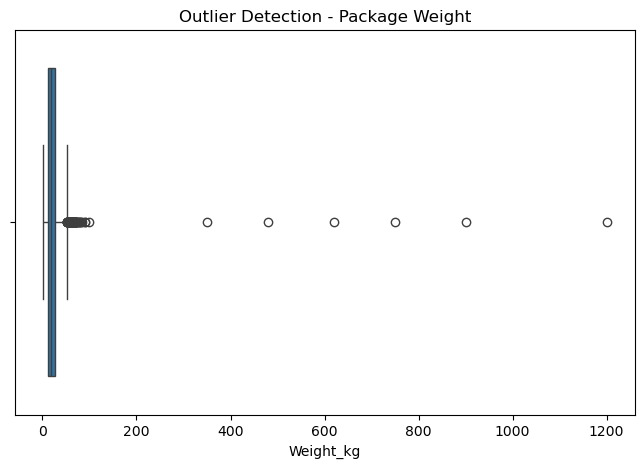

In [129]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["Weight_kg"])
plt.title("Outlier Detection - Package Weight")
plt.show()

### Cost

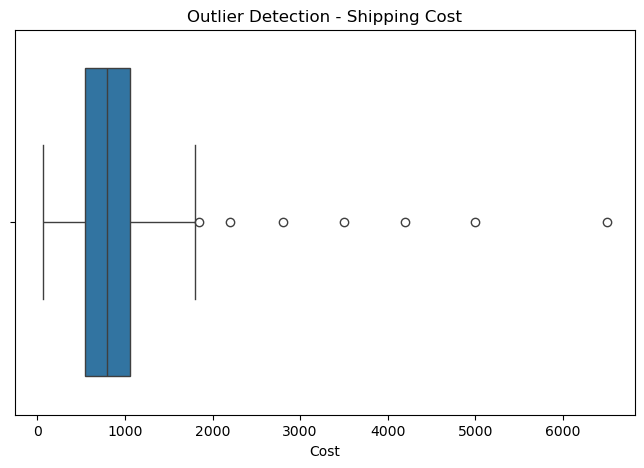

In [130]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["Cost"])
plt.title("Outlier Detection - Shipping Cost")
plt.show()

### Distance

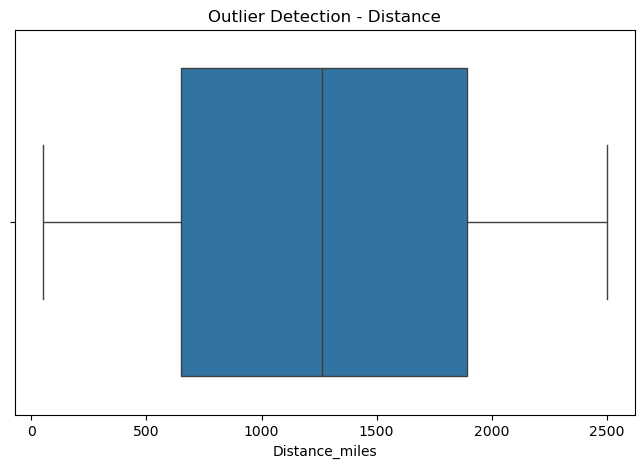

In [131]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["Distance_miles"])
plt.title("Outlier Detection - Distance")
plt.show()

### Transit Days

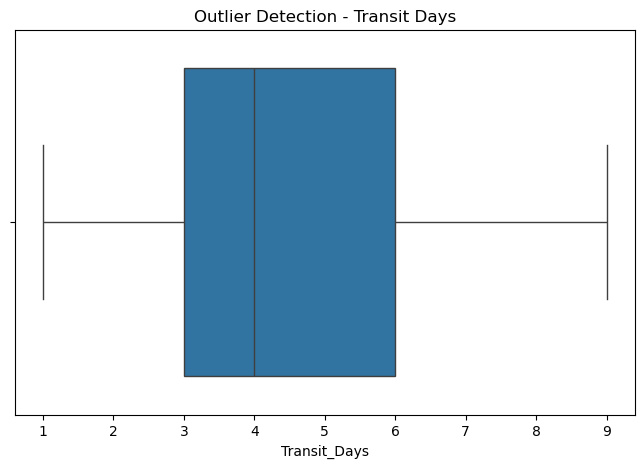

In [132]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean["Transit_Days"])
plt.title("Outlier Detection - Transit Days")
plt.show()

### 13.1 IQR-Based Outlier Detection

In [133]:
for column in numerical_columns:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]
    
    print(
        f"{column}: {len(outliers)} outliers"
    )

Weight_kg: 77 outliers
Cost: 7 outliers
Distance_miles: 0 outliers
Transit_Days: 0 outliers


## 14. Numerical Data Normalization

In [134]:
from sklearn.preprocessing import MinMaxScaler

scale_columns = [
    "Weight_kg",
    "Cost",
    "Distance_miles",
    "Transit_Days"
]

df_normalized = df_clean.copy()

In [135]:
scaler = MinMaxScaler()

df_normalized[scale_columns] = scaler.fit_transform(
    df_normalized[scale_columns]
)

In [136]:
df_normalized[scale_columns].describe()

,Weight_kg,Cost,Distance_miles,Transit_Days
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.018246,0.115501,0.502358,0.404125
std,0.035979,0.057767,0.287773,0.211732
min,0.000000,0.000000,0.000000,0.000000
25%,0.008259,0.073672,0.245507,0.250000
50%,0.014349,0.113490,0.494894,0.375000
75%,0.021857,0.154050,0.751634,0.625000
max,1.000000,1.000000,1.000000,1.000000


## 15. Validation of Cleaned Dataset

In [114]:
df_clean.isnull().sum()


Shipment_ID         0
Origin_Warehouse    0
Destination         0
Carrier             0
Shipment_Date       0
Delivery_Date       0
Weight_kg           0
Cost                0
Status              0
Distance_miles      0
Transit_Days        0
Invalid_Date        0
dtype: int64

In [115]:
df_clean.duplicated().sum()

np.int64(0)

In [116]:
df_clean.dtypes

Shipment_ID                 object
Origin_Warehouse            object
Destination                 object
Carrier                     object
Shipment_Date       datetime64[ns]
Delivery_Date       datetime64[ns]
Weight_kg                  float64
Cost                       float64
Status              string[python]
Distance_miles               int64
Transit_Days                 int64
Invalid_Date                  bool
dtype: object

In [117]:
df_clean.shape

(2000, 12)

In [118]:
df_clean.head()

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,Invalid_Date
0,SH10001,Mumbai_Warehouse,Hyderabad,DHL,2025-02-02,2025-02-08,8.1,979.63,Delivered,2202,6,False
1,SH10002,Delhi_Warehouse,Kolkata,Delhivery,2025-10-10,2025-10-14,6.9,186.22,Delivered,202,4,False
2,SH10003,Bengaluru_Warehouse,Ahmedabad,BlueDart,2025-08-27,2025-08-30,11.6,685.09,Delivered,1024,3,False
3,SH10004,Delhi_Warehouse,Kolkata,DHL,2025-06-10,2025-06-14,11.1,646.05,Delivered,1173,4,False
4,SH10005,Hyderabad_Warehouse,Delhi,Delhivery,2025-06-08,2025-06-14,15.1,1044.77,Delivered,2005,6,False


## 16. Before and After Cleaning Comparison

In [124]:
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values before cleaning:")
print(df.isnull().sum())

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nDuplicates before cleaning:", df.duplicated().sum())
print("Duplicates after cleaning:", df_clean.duplicated().sum())

Original dataset shape: (2010, 11)
Cleaned dataset shape: (2000, 12)

Missing values before cleaning:
Shipment_ID          0
Origin_Warehouse     0
Destination          0
Carrier              5
Shipment_Date        0
Delivery_Date       29
Weight_kg            0
Cost                40
Status               0
Distance_miles       0
Transit_Days         0
dtype: int64

Missing values after cleaning:
Shipment_ID         0
Origin_Warehouse    0
Destination         0
Carrier             0
Shipment_Date       0
Delivery_Date       0
Weight_kg           0
Cost                0
Status              0
Distance_miles      0
Transit_Days        0
Invalid_Date        0
dtype: int64

Duplicates before cleaning: 10
Duplicates after cleaning: 0


## 17. Final Cleaned Dataset

In [120]:
df_clean.head(10)

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,Invalid_Date
0,SH10001,Mumbai_Warehouse,Hyderabad,DHL,2025-02-02,2025-02-08,8.1,979.63,Delivered,2202,6,False
1,SH10002,Delhi_Warehouse,Kolkata,Delhivery,2025-10-10,2025-10-14,6.9,186.22,Delivered,202,4,False
2,SH10003,Bengaluru_Warehouse,Ahmedabad,BlueDart,2025-08-27,2025-08-30,11.6,685.09,Delivered,1024,3,False
3,SH10004,Delhi_Warehouse,Kolkata,DHL,2025-06-10,2025-06-14,11.1,646.05,Delivered,1173,4,False
4,SH10005,Hyderabad_Warehouse,Delhi,Delhivery,2025-06-08,2025-06-14,15.1,1044.77,Delivered,2005,6,False
5,SH10006,Bengaluru_Warehouse,Chennai,Delhivery,2025-11-10,2025-11-11,24.5,449.70,Delivered,366,1,False
6,SH10007,Ahmedabad_Warehouse,Ahmedabad,Ecom Express,2025-02-01,2025-02-06,16.7,811.41,Delivered,1113,5,False
7,SH10008,Ahmedabad_Warehouse,Nashik,FedEx,2025-09-12,2025-09-15,29.6,509.75,Delivered,423,3,False
8,SH10009,Delhi_Warehouse,Nashik,Delhivery,2025-03-15,2025-03-22,14.3,1093.32,Delivered,1980,7,False
9,SH10010,Ahmedabad_Warehouse,Delhi,XpressBees,2025-02-04,2025-02-10,48.5,1130.93,Delivered,1599,6,False


In [121]:
df_clean.to_csv(
    "logistics_shipment_data_cleaned.csv",
    index=False
)

In [122]:
df_clean.to_csv(
    "logistics_shipment_data_cleaned.csv",
    index=False
)

## 18. Reflection



Data quality is essential for reliable logistics analysis. Missing values, duplicates, inconsistent categories, invalid dates, and outliers can affect KPIs and predictive models. In this project, missing values were handled using median/mode imputation, duplicates were removed, data types and categories were standardized, and invalid dates were investigated. Outliers were identified using IQR and retained when they could represent legitimate logistics activity. Numerical variables were normalized using Min-Max scaling for future analysis and machine-learning applications.

## 19. Conclusion


In [123]:
The logistics shipment dataset was successfully collected, inspected, cleaned, and preprocessed using Python. The analysis demonstrated a complete data-preparation workflow, including missing-value analysis, duplicate detection, data-type correction, categorical standardization, invalid-date identification, outlier detection, and numerical normalization. The resulting cleaned dataset provides a stronger foundation for future exploratory data analysis, KPI development, visualization, and predictive modeling. This preprocessing stage can help logistics organizations make more reliable decisions regarding shipment costs, delivery performance, resource allocation, and operational efficiency.

SyntaxError: invalid syntax (2555071316.py, line 1)